In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2

/zhome/99/b/213811/thesis/DIFF-UQ/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
real_dataset_path = f_chkpt_dir(0) + "/real_dataset.npy"
real_data = np.load(real_dataset_path)
print(real_data.shape)

(100000, 2)


In [3]:
ensemble_samples = np.load(cache_path)
print(ensemble_samples.shape)
base_samples = ensemble_samples[0]

(6, 100000, 2)


In [4]:
uncertainty_calc_method = "diagonal_gaussian_entropy" # "diagonal_gaussian_entropy", "full_gaussian_entropy", "raw_variance"
uncertainty_scores = f_uncertainty_scores(ensemble_samples, kind=uncertainty_calc_method)

In [18]:
def calculate_wasserstein(real_data, generated_data):
    """Calculates the 2-Wasserstein distance between two 2D distributions."""
    # Subsample to speed up calculation if datasets are huge (e.g., 5000 points)
    assert len(real_data) <= 5000 and len(generated_data) <= 5000, "Subsample the data to at most 5000 points for efficiency."
    assert len(real_data) == len(generated_data)
    n = len(real_data)
    
    # Calculate pairwise Euclidean distance matrix
    M = ot.dist(real_data, generated_data, metric='euclidean')
    
    # Uniform weights for all points
    a, b = np.ones((n,)) / n, np.ones((n,)) / n
    
    # Calculate exact Earth Mover's Distance
    wasserstein_dist = ot.emd2(a, b, M)
    # wasserstein_dist = ot.sinkhorn2(a, b, M, reg=0.01, numItermax=10000)[0]
    return wasserstein_dist

In [6]:
percentile_score = np.percentile(uncertainty_scores, 80)
confident_mask = uncertainty_scores <= percentile_score
filtered_samples = base_samples[confident_mask]

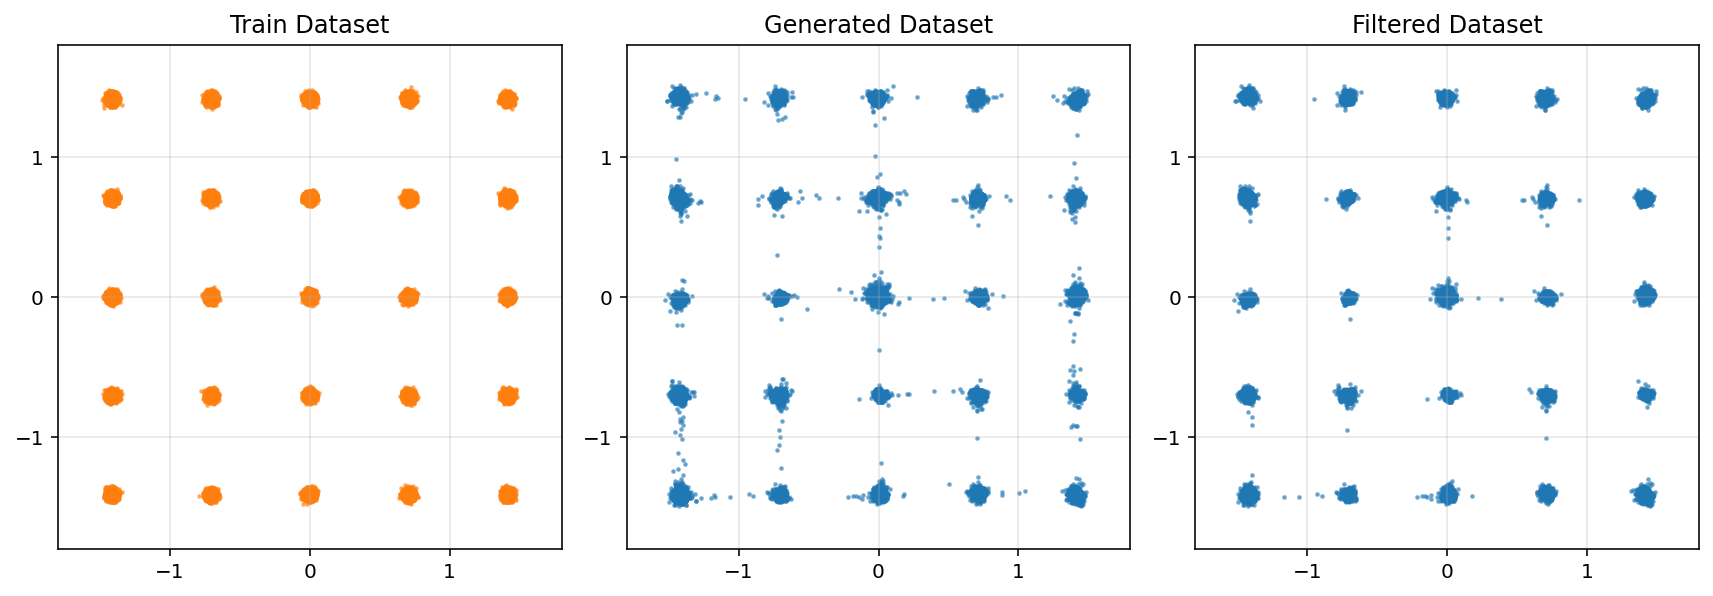

In [8]:
plot_samples_filtering(base_samples, filtered_samples, save_fig=False)